In [2]:
import ale_py
import copy
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Используется GPU на Apple Silicon (MPS)")
else:
    device = torch.device("cpu")
    print("MPS недоступен, используется CPU")

env = gym.make("PongNoFrameskip-v4", render_mode="rgb_array")

Используется GPU на Apple Silicon (MPS)


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [3]:
ACTIONS = [0, 2, 3] # 'NOOP', 'RIGHT', 'LEFT'
n_action = 3

In [4]:
image_size = 84

def get_state(obs):
    gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (image_size, image_size), interpolation=cv2.INTER_AREA)
    state_np = resized.astype(np.float32) / 255.0
    state_tensor = torch.from_numpy(state_np).unsqueeze(0).unsqueeze(0)
    return state_tensor

obs, _ = env.reset()
state = get_state(obs)
print("Размерность состояния:", state.shape)

Размерность состояния: torch.Size([1, 1, 84, 84])


# Model

In [5]:
class DenseModel(nn.Module):
    def __init__(self, input_size, n_action):
        super(DenseModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.out = nn.Linear(256, n_action)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        output = self.out(x)
        return output

class DQN():
    def __init__(self, input_size, n_action, lr=0.0003):
        self.criterion = nn.MSELoss()
        self.model = DenseModel(input_size, n_action).to(device)
        self.model_target = copy.deepcopy(self.model).to(device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr)

    def copy_target(self):
        self.model_target.load_state_dict(self.model.state_dict())

    def update(self, states, targets):
        self.optimizer.zero_grad()
        outputs = self.model(states)
        loss = self.criterion(outputs, targets)
        loss.backward()
        self.optimizer.step()

    def predict(self, s):
        with torch.no_grad():
            return self.model(s.to(device).float())

    def target_predict(self, s):
        with torch.no_grad():
            return self.model_target(s.to(device).float())

    def replay(self, memory, replay_size, gamma):
        if len(memory) < replay_size:
            return

        replay_data = random.sample(memory, replay_size)

        states = torch.cat([ex[0] for ex in replay_data]).to(device).float()
        actions = [ex[1] for ex in replay_data]
        next_states = torch.cat([ex[2] for ex in replay_data]).to(device).float()
        rewards = [ex[3] for ex in replay_data]
        dones = [ex[4] for ex in replay_data]

        q_targets = self.model(states).detach()
        next_q_values = self.target_predict(next_states).max(1)[0]

        for i in range(replay_size):
            action_idx = actions[i]
            if dones[i]:
                q_targets[i][action_idx] = rewards[i]
            else:
                q_targets[i][action_idx] = rewards[i] + gamma * next_q_values[i].item()

        self.update(states, q_targets)

## Epsilon-greed

In [6]:
def gen_epsilon_greedy_policy(estimator, epsilon, n_action):
    def policy_function(state):
        if random.random() < epsilon:
            return random.randint(0, n_action - 1)
        else:
            q_values = estimator.predict(state)
            return torch.argmax(q_values).item()
    return policy_function

In [7]:
n_action = 3
input_size = image_size * image_size * 1

lr = 0.0003
target_update = 5
n_episode = 50
replay_size = 32

total_reward_episode = [0] * n_episode

dqn = DQN(input_size, n_action, lr)

In [8]:
memory = deque(maxlen=10000)

## Q-learn

In [9]:
def q_learning(env, estimator, n_episode, replay_size, target_update=10, gamma=0.99, epsilon=1.0, epsilon_decay=0.95):
    for episode in range(n_episode):
        if episode % target_update == 0:
            estimator.copy_target()

        policy = gen_epsilon_greedy_policy(estimator, epsilon, n_action)
        obs, _ = env.reset()
        state = get_state(obs)

        while True:
            action = policy(state)

            next_obs, reward, done, truncated, _ = env.step(ACTIONS[action])
            total_reward_episode[episode] += reward

            next_state = get_state(next_obs)

            memory.append((state, action, next_state, reward, done or truncated))

            if done or truncated:
                break

            estimator.replay(memory, replay_size, gamma)
            state = next_state

        print('Эпизод: {}, полное вознаграждение: {:.1f}, epsilon: {:.3f}'.
                    format(episode, total_reward_episode[episode], epsilon))

        epsilon = max(epsilon * epsilon_decay, 0.05)

## Train

In [11]:
q_learning(env, dqn, n_episode, replay_size, target_update, gamma=0.99, epsilon=1.0, epsilon_decay=0.98)

Эпизод: 0, полное вознаграждение: -41.0, epsilon: 1.000
Эпизод: 1, полное вознаграждение: -42.0, epsilon: 0.980
Эпизод: 2, полное вознаграждение: -42.0, epsilon: 0.960
Эпизод: 3, полное вознаграждение: -42.0, epsilon: 0.941
Эпизод: 4, полное вознаграждение: -40.0, epsilon: 0.922
Эпизод: 5, полное вознаграждение: -22.0, epsilon: 0.904
Эпизод: 6, полное вознаграждение: -20.0, epsilon: 0.886
Эпизод: 7, полное вознаграждение: -21.0, epsilon: 0.868
Эпизод: 8, полное вознаграждение: -21.0, epsilon: 0.851
Эпизод: 9, полное вознаграждение: -21.0, epsilon: 0.834
Эпизод: 10, полное вознаграждение: -21.0, epsilon: 0.817
Эпизод: 11, полное вознаграждение: -21.0, epsilon: 0.801
Эпизод: 12, полное вознаграждение: -21.0, epsilon: 0.785
Эпизод: 13, полное вознаграждение: -21.0, epsilon: 0.769
Эпизод: 14, полное вознаграждение: -21.0, epsilon: 0.754
Эпизод: 15, полное вознаграждение: -21.0, epsilon: 0.739
Эпизод: 16, полное вознаграждение: -21.0, epsilon: 0.724
Эпизод: 17, полное вознаграждение: -21.0,

# Charts

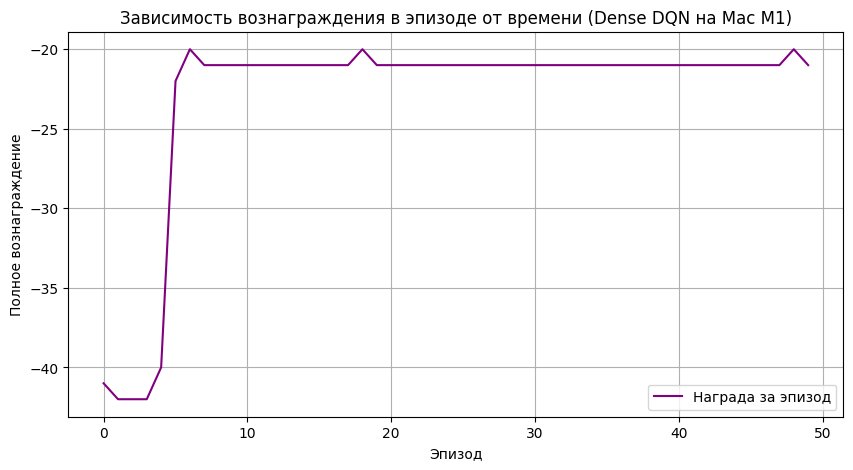

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(total_reward_episode, label='Награда за эпизод', color='purple')
plt.title('Зависимость вознаграждения в эпизоде от времени (Dense DQN на Mac M1)')
plt.xlabel('Эпизод')
plt.ylabel('Полное вознаграждение')
plt.grid(True)
plt.legend()
plt.show()